In [1]:
print("Kelompok SSJ")
print("Listianto Hilmi Fauzaan | 103012400094")
print("Muhammad Daffa | 103012400110")
print("Moch. Firmansyah | 103012400137")

Kelompok SSJ
Listianto Hilmi Fauzaan | 103012400094
Muhammad Daffa | 103012400110
Moch. Firmansyah | 103012400137


# Fuzzy Inference System — Risiko Kardiovaskular
| | |
| :--- | :--- |
| **Dataset** | Cardiovascular Disease Dataset |
| **Sumber** | https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset |
| **Jumlah Data** | 70.000 baris, 13 variabel |
| **Topik** | Prediksi Penyakit Kardiovaskular |
| **Metode** | Fuzzy Mamdani & Fuzzy Sugeno (from scratch, tanpa library fuzzy) |
|**Input** | Usia, Tekanan Darah Sistolik (ap_hi), BMI |


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

## 1. Membership Functions (dari scratch)

In [3]:
# Trapezoidal MF
def trapmf(x, a, b, c, d):
    if x <= a or x >= d: return 0.0
    if b <= x <= c:       return 1.0
    if x < b:             return (x - a) / (b - a)
    return (d - x) / (d - c)

# Triangular MF
def trimf(x, a, b, c):
    if x <= a or x >= c: return 0.0
    if x <= b:            return (x - a) / (b - a)
    return (c - x) / (c - b)

## 2. Definisi Himpunan Fuzzy Input & Output

In [4]:
# --- USIA ---
def mu_usia_muda(x):   return trapmf(x, 20, 25, 40, 50)
def mu_usia_sedang(x): return trapmf(x, 40, 50, 55, 62)
def mu_usia_tua(x):    return trapmf(x, 55, 62, 70, 75)

# --- TEKANAN DARAH SISTOLIK (ap_hi) ---
def mu_bp_normal(x):   return trapmf(x, 60, 70, 110, 125)
def mu_bp_pre(x):      return trapmf(x, 110, 125, 135, 145)
def mu_bp_hiper(x):    return trapmf(x, 135, 145, 200, 250)


# --- TEKANAN DARAH DIASTOLIK (ap_lo) ---
def mu_bplo_normal(x): return trapmf(x, 40, 60, 80, 85)
def mu_bplo_pre(x):    return trapmf(x, 80, 85, 90, 100)
def mu_bplo_hiper(x):  return trapmf(x, 90, 100, 150, 180)

# --- KOLESTEROL ---
def mu_chol_normal(x): return trimf(x, 0, 1, 2)
def mu_chol_tinggi(x): return trimf(x, 1, 3, 4)

# --- BMI ---
def mu_bmi_normal(x):  return trapmf(x, 10, 15, 22, 26)
def mu_bmi_over(x):    return trapmf(x, 22, 26, 28, 32)
def mu_bmi_obese(x):   return trapmf(x, 28, 32, 55, 60)

# --- OUTPUT: RISIKO (Mamdani) ---
def mu_risk_rendah(s): return trapmf(s, -5, 0, 25, 45)
def mu_risk_sedang(s): return trimf(s, 30, 50, 70)
def mu_risk_tinggi(s): return trapmf(s, 55, 75, 100, 105)

# --- OUTPUT: RISIKO (Sugeno — singleton) ---
SUGENO_SINGLETON = {'rendah': 20.0, 'sedang': 50.0, 'tinggi': 85.0}

OUTPUT_MF = {
    'rendah': mu_risk_rendah,
    'sedang': mu_risk_sedang,
    'tinggi': mu_risk_tinggi,
}

## 3. Rule Base (27 Aturan)

In [5]:
RULES = [
    # (fn_usia, fn_bp, fn_bplo, fn_bmi, fn_chol, konsekuen)
    (mu_usia_muda,   mu_bp_normal, mu_bplo_normal, mu_bmi_normal, mu_chol_normal, 'rendah'),
    (mu_usia_muda,   mu_bp_normal, mu_bplo_normal, mu_bmi_over,   mu_chol_normal, 'rendah'),
    (mu_usia_muda,   mu_bp_normal, mu_bplo_normal, mu_bmi_obese,  mu_chol_normal, 'sedang'),
    (mu_usia_muda,   mu_bp_pre,    mu_bplo_pre,    mu_bmi_normal, mu_chol_normal, 'rendah'),
    (mu_usia_muda,   mu_bp_pre,    mu_bplo_pre,    mu_bmi_over,   mu_chol_tinggi, 'sedang'),
    (mu_usia_muda,   mu_bp_hiper,  mu_bplo_hiper,  mu_bmi_obese,  mu_chol_tinggi, 'tinggi'),
    (mu_usia_muda,   mu_bp_hiper,  mu_bplo_hiper,  mu_bmi_normal, mu_chol_tinggi, 'sedang'),
    (mu_usia_sedang, mu_bp_normal, mu_bplo_normal, mu_bmi_normal, mu_chol_normal, 'rendah'),
    (mu_usia_sedang, mu_bp_normal, mu_bplo_normal, mu_bmi_over,   mu_chol_normal, 'sedang'),
    (mu_usia_sedang, mu_bp_normal, mu_bplo_pre,    mu_bmi_obese,  mu_chol_tinggi, 'sedang'),
    (mu_usia_sedang, mu_bp_pre,    mu_bplo_pre,    mu_bmi_normal, mu_chol_normal, 'sedang'),
    (mu_usia_sedang, mu_bp_pre,    mu_bplo_pre,    mu_bmi_over,   mu_chol_tinggi, 'tinggi'),
    (mu_usia_sedang, mu_bp_hiper,  mu_bplo_hiper,  mu_bmi_obese,  mu_chol_tinggi, 'tinggi'),
    (mu_usia_sedang, mu_bp_hiper,  mu_bplo_hiper,  mu_bmi_normal, mu_chol_normal, 'sedang'),
    (mu_usia_tua,    mu_bp_normal, mu_bplo_normal, mu_bmi_normal, mu_chol_normal, 'sedang'),
    (mu_usia_tua,    mu_bp_normal, mu_bplo_normal, mu_bmi_over,   mu_chol_tinggi, 'tinggi'),
    (mu_usia_tua,    mu_bp_pre,    mu_bplo_pre,    mu_bmi_normal, mu_chol_normal, 'sedang'),
    (mu_usia_tua,    mu_bp_pre,    mu_bplo_pre,    mu_bmi_over,   mu_chol_tinggi, 'tinggi'),
    (mu_usia_tua,    mu_bp_pre,    mu_bplo_hiper,  mu_bmi_obese,  mu_chol_tinggi, 'tinggi'),
    (mu_usia_tua,    mu_bp_hiper,  mu_bplo_hiper,  mu_bmi_normal, mu_chol_normal, 'tinggi'),
    (mu_usia_tua,    mu_bp_hiper,  mu_bplo_hiper,  mu_bmi_over,   mu_chol_tinggi, 'tinggi'),
    (mu_usia_tua,    mu_bp_hiper,  mu_bplo_hiper,  mu_bmi_obese,  mu_chol_tinggi, 'tinggi'),
    (mu_usia_muda,   mu_bp_normal, mu_bplo_hiper,  mu_bmi_normal, mu_chol_tinggi, 'sedang'),
    (mu_usia_sedang, mu_bp_normal, mu_bplo_hiper,  mu_bmi_over,   mu_chol_tinggi, 'tinggi'),
    (mu_usia_tua,    mu_bp_hiper,  mu_bplo_normal, mu_bmi_obese,  mu_chol_normal, 'tinggi'),
]

## 4. Fuzzifikasi & Evaluasi Rule

In [6]:
def fuzzifikasi(usia, bp, bmi, ap_lo, chol):
    """Mengembalikan derajat keanggotaan semua variabel input."""
    return {
        'usia_muda'  : mu_usia_muda(usia),
        'usia_sedang': mu_usia_sedang(usia),
        'usia_tua'   : mu_usia_tua(usia),
        'bp_normal'  : mu_bp_normal(bp),
        'bp_pre'     : mu_bp_pre(bp),
        'bp_hiper'   : mu_bp_hiper(bp),
        'bmi_normal' : mu_bmi_normal(bmi),
        'bmi_over'   : mu_bmi_over(bmi),
        'bmi_obese'  : mu_bmi_obese(bmi),
        'bplo_normal': mu_bplo_normal(ap_lo),
        'bplo_pre'   : mu_bplo_pre(ap_lo),
        'bplo_hiper' : mu_bplo_hiper(ap_lo),
        'chol_normal': mu_chol_normal(chol),
        'chol_tinggi': mu_chol_tinggi(chol),

    }

def evaluasi_rule(usia, bp, bmi, ap_lo, chol):
    """Hitung firing strength (alpha) tiap rule dengan operator AND = min."""
    result = []
    for (fn_usia, fn_bp, fn_bplo, fn_bmi, fn_chol, konsekuen) in RULES:
        alpha = min(fn_usia(usia), fn_bp(bp), fn_bplo(ap_lo), fn_bmi(bmi), fn_chol(chol))
        result.append((alpha, konsekuen))
    return result

## 5. Inferensi Mamdani (Centroid Defuzzifikasi)

In [7]:
def mamdani_inferensi(usia, bp, bmi, ap_lo, chol, n=400):
    """
    Mamdani FIS:
      1. Evaluasi rule → firing strength (alpha)
      2. Clipping tiap MF output dengan alpha-nya
      3. Agregasi (max)
      4. Defuzzifikasi centroid
    """
    firing = evaluasi_rule(usia, bp, bmi, ap_lo, chol)
    S_vals = np.linspace(0, 100, n)
    agg    = np.zeros(n)
    for (alpha, konsekuen) in firing:
        mf_fn = OUTPUT_MF[konsekuen]
        for i, s in enumerate(S_vals):
            agg[i] = max(agg[i], min(alpha, mf_fn(s)))
    denom  = np.sum(agg)
    output = float(np.sum(S_vals * agg) / denom) if denom > 0 else 50.0
    return output

## 6. Inferensi Sugeno (Weighted Average)

In [8]:
def sugeno_inferensi(usia, bp, bmi, ap_lo, chol):
    """
    Sugeno (Zero-Order) FIS:
      Output = Σ(alpha_i × z_i) / Σ(alpha_i)
      di mana z_i adalah singleton konstanta tiap konsekuen.
    """
    firing = evaluasi_rule(usia, bp, bmi, ap_lo, chol)
    num = sum(a * SUGENO_SINGLETON[k] for (a, k) in firing)
    den = sum(a for (a, _) in firing)
    return float(num / den) if den > 0 else 50.0

def label_risiko(score):
    """Konversi skor ke label kategori."""
    if score < 40:  return 'Rendah'
    if score < 65:  return 'Sedang'
    return 'Tinggi'

## 7. Visualisasi — Mamdani Aggregation

In [9]:
def plot_mamdani(usia, bp, bmi, ap_lo, chol):
    """Visualisasi proses agregasi & defuzzifikasi Mamdani."""
    firing  = evaluasi_rule(usia, bp, bmi, ap_lo, chol)
    S_vals  = np.linspace(0, 100, 400)

    # Hitung alpha dominan per konsekuen
    alpha_per = {'rendah': 0.0, 'sedang': 0.0, 'tinggi': 0.0}
    for (a, k) in firing:
        alpha_per[k] = max(alpha_per[k], a)

    alpha_rendah = round(alpha_per['rendah'], 3)
    alpha_sedang = round(alpha_per['sedang'], 3)
    alpha_tinggi = round(alpha_per['tinggi'], 3)

    # Truncated MF
    y_rendah_trunc = np.array([min(alpha_rendah, mu_risk_rendah(s)) for s in S_vals])
    y_sedang_trunc = np.array([min(alpha_sedang, mu_risk_sedang(s)) for s in S_vals])
    y_tinggi_trunc = np.array([min(alpha_tinggi, mu_risk_tinggi(s)) for s in S_vals])

    # Aggregation
    y_agg = np.maximum(np.maximum(y_rendah_trunc, y_sedang_trunc), y_tinggi_trunc)

    # Centroid
    denom   = np.sum(y_agg)
    centroid = float(np.sum(S_vals * y_agg) / denom) if denom > 0 else 50.0

    # --- Plot ---
    BG   = '#0d1117'
    CARD = '#161b22'
    fig  = plt.figure(figsize=(11, 6), facecolor=BG)
    ax   = fig.add_subplot(111, facecolor=CARD)

    BLUE   = '#3b82f6'
    GREEN  = '#10b981'
    AMBER  = '#f59e0b'
    LBLUE  = '#60a5fa'
    GRID   = '#21262d'

    ax.fill_between(S_vals, 0, y_rendah_trunc, color=BLUE,  alpha=0.25)
    ax.fill_between(S_vals, 0, y_sedang_trunc, color=GREEN, alpha=0.25)
    ax.fill_between(S_vals, 0, y_tinggi_trunc, color=AMBER, alpha=0.25)

    ax.plot(S_vals, y_rendah_trunc, color=BLUE,  lw=2,   label=f'Rendah  (α={alpha_rendah})')
    ax.plot(S_vals, y_sedang_trunc, color=GREEN, lw=2,   label=f'Sedang  (α={alpha_sedang})')
    ax.plot(S_vals, y_tinggi_trunc, color=AMBER, lw=2,   label=f'Tinggi  (α={alpha_tinggi})')
    ax.fill_between(S_vals, 0, y_agg, color='#1e293b', alpha=0.55, label='Aggregated Area')
    ax.plot(S_vals, y_agg, color=LBLUE, lw=2.5, linestyle='-', alpha=0.9)
    ax.axvline(x=centroid, color='#ffffff', ls=':', lw=2,
               label=f'Centroid ({centroid:.1f}%)')
    ax.text(centroid + 1.5, 1.02, f'{centroid:.1f}%',
            color='#ffffff', fontsize=10, fontweight='bold', va='bottom')

    ax.set_title('Mamdani — Agregasi & Defuzzifikasi',
                 color='#ffffff', fontsize=14, fontweight='bold', pad=12, loc='left')
    ax.set_xlabel('Risk Level (%)', color='#8b949e', fontsize=11)
    ax.set_ylabel('Membership (μ)', color='#8b949e', fontsize=11)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1.15)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.tick_params(colors='#8b949e', labelsize=10)
    ax.grid(True, color=GRID, lw=0.8)
    for spine in ax.spines.values(): spine.set_color(GRID)

    legend = ax.legend(loc='upper left', facecolor='#1c2028',
                       edgecolor=GRID, labelcolor='#c9d1d9', fontsize=10)

    # Info box
    info = (f'Input  →  Usia: {usia:.1f} th | BP Sistolik: {bp} mmHg | BP Diastolik: {ap_lo} mmHg | BMI: {bmi:.1f} | Kolesterol: {chol}\n'
            f'Output →  Centroid Mamdani: {centroid:.2f}%  |  Kategori: {label_risiko(centroid)}')
    fig.text(0.5, 0.01, info, ha='center', color='#8b949e', fontsize=10,
             bbox=dict(fc='#161b22', ec=GRID, pad=5))
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    plt.show()
    return centroid

## 8. Visualisasi — Sugeno Inference

In [10]:
def plot_sugeno(usia, bp, bmi, ap_lo, chol):
    """
    Visualisasi Sugeno:
      - Bar chart: firing strength tiap rule yang aktif
      - Scatter: singleton output ter-weight oleh alpha
      - Garis: weighted average (output akhir)
    """
    firing = evaluasi_rule(usia, bp, bmi, ap_lo, chol)

    # Filter rule aktif (alpha > 0)
    active = [(i+1, a, k) for i, (a, k) in enumerate(firing) if a > 0]

    sugeno_out = sugeno_inferensi(usia, bp, bmi, ap_lo, chol)

    COLOR_MAP = {'rendah': '#3b82f6', 'sedang': '#10b981', 'tinggi': '#f59e0b'}
    BG   = '#0d1117'
    CARD = '#161b22'
    GRID = '#21262d'

    fig = plt.figure(figsize=(13, 12), facecolor=BG)
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Panel 1: MF Input Usia ────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0], facecolor=CARD)
    u_x = np.linspace(20, 80, 500)
    ax1.plot(u_x, [mu_usia_muda(v) for v in u_x],   color='#3b82f6', lw=2, label='Muda')
    ax1.plot(u_x, [mu_usia_sedang(v) for v in u_x], color='#10b981', lw=2, label='Sedang')
    ax1.plot(u_x, [mu_usia_tua(v) for v in u_x],    color='#f59e0b', lw=2, label='Tua')
    ax1.axvline(usia, color='#ff6b6b', ls='--', lw=1.5, label=f'Input={usia:.1f}')
    ax1.set_title('Fungsi Keanggotaan (MF) Usia', color='#c9d1d9', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Usia (tahun)', color='#8b949e', fontsize=9)
    ax1.set_ylabel('μ', color='#8b949e', fontsize=10)
    ax1.legend(facecolor='#1c2028', edgecolor=GRID, labelcolor='#c9d1d9', fontsize=8)
    ax1.grid(True, color=GRID, lw=0.6); [s.set_color(GRID) for s in ax1.spines.values()]
    ax1.tick_params(colors='#8b949e', labelsize=8)

    # ── Panel 2: MF Input Tekanan Darah ──────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1], facecolor=CARD)
    b_x = np.linspace(50, 260, 500)
    ax2.plot(b_x, [mu_bp_normal(v) for v in b_x], color='#3b82f6', lw=2, label='Normal')
    ax2.plot(b_x, [mu_bp_pre(v) for v in b_x],    color='#10b981', lw=2, label='Pre-Hiper')
    ax2.plot(b_x, [mu_bp_hiper(v) for v in b_x],  color='#f59e0b', lw=2, label='Hipertensi')
    ax2.axvline(bp, color='#ff6b6b', ls='--', lw=1.5, label=f'Input={bp}')
    ax2.set_title('MF Tekanan Darah (ap_hi)', color='#c9d1d9', fontsize=11, fontweight='bold')
    ax2.set_xlabel('BP Sistolik (mmHg)', color='#8b949e', fontsize=9)
    ax2.set_ylabel('μ', color='#8b949e', fontsize=10)
    ax2.legend(facecolor='#1c2028', edgecolor=GRID, labelcolor='#c9d1d9', fontsize=8)
    ax2.grid(True, color=GRID, lw=0.6); [s.set_color(GRID) for s in ax2.spines.values()]
    ax2.tick_params(colors='#8b949e', labelsize=8)

    # ── Panel Tambahan: MF Diastolik & Kolesterol ────────────────────
    ax_bplo = fig.add_subplot(gs[1, 0], facecolor=CARD)
    bplo_x = np.linspace(30, 200, 500)
    ax_bplo.plot(bplo_x, [mu_bplo_normal(v) for v in bplo_x], color='#3b82f6', lw=2, label='Normal')
    ax_bplo.plot(bplo_x, [mu_bplo_pre(v) for v in bplo_x],    color='#10b981', lw=2, label='Pre-Hiper')
    ax_bplo.plot(bplo_x, [mu_bplo_hiper(v) for v in bplo_x],  color='#f59e0b', lw=2, label='Hipertensi')
    ax_bplo.axvline(ap_lo, color='#ff6b6b', ls='--', lw=1.5, label=f'Input={ap_lo}')
    ax_bplo.set_title('Fungsi Keanggotaan (MF) Tekanan Diastolik', color='#c9d1d9', fontsize=11, fontweight='bold')
    ax_bplo.set_ylabel('μ', color='#8b949e', fontsize=10)
    ax_bplo.grid(True, color=GRID, lw=0.6); [s.set_color(GRID) for s in ax_bplo.spines.values()]
    ax_bplo.tick_params(colors='#8b949e', labelsize=8)

    ax_chol = fig.add_subplot(gs[1, 1], facecolor=CARD)
    chol_x = np.linspace(0, 5, 100)
    ax_chol.plot(chol_x, [mu_chol_normal(v) for v in chol_x], color='#3b82f6', lw=2, label='Normal')
    ax_chol.plot(chol_x, [mu_chol_tinggi(v) for v in chol_x], color='#f59e0b', lw=2, label='Tinggi')
    ax_chol.axvline(chol, color='#ff6b6b', ls='--', lw=1.5, label=f'Input={chol}')
    ax_chol.set_title('Fungsi Keanggotaan (MF) Tingkat Kolesterol', color='#c9d1d9', fontsize=11, fontweight='bold')
    ax_chol.set_ylabel('μ', color='#8b949e', fontsize=10)
    ax_chol.grid(True, color=GRID, lw=0.6); [s.set_color(GRID) for s in ax_chol.spines.values()]
    ax_chol.tick_params(colors='#8b949e', labelsize=8)

    # ── Panel 3: Firing Strength Rule Aktif ──────────────────────────────
    ax3 = fig.add_subplot(gs[2, 0], facecolor=CARD)
    if active:
        rule_ids = [f'R{r}' for (r, a, k) in active]
        alphas   = [a for (r, a, k) in active]
        colors   = [COLOR_MAP[k] for (r, a, k) in active]
        bars = ax3.barh(rule_ids, alphas, color=colors, edgecolor=GRID, height=0.6)
        for bar, alpha in zip(bars, alphas):
            ax3.text(alpha + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{alpha:.3f}', va='center', color='#c9d1d9', fontsize=8)
    ax3.set_xlim(0, 1.15)
    ax3.set_title('Kekuatan Aturan Aktif (Firing Strength)', color='#c9d1d9', fontsize=11, fontweight='bold')
    ax3.set_xlabel('Firing Strength', color='#8b949e', fontsize=9)
    # Legenda warna konsekuen
    patches = [mpatches.Patch(color=COLOR_MAP[k], label=k.capitalize()) for k in COLOR_MAP]
    ax3.legend(handles=patches, facecolor='#1c2028', edgecolor=GRID,
               labelcolor='#c9d1d9', fontsize=8, loc='lower right')
    ax3.grid(True, axis='x', color=GRID, lw=0.6)
    [s.set_color(GRID) for s in ax3.spines.values()]
    ax3.tick_params(colors='#8b949e', labelsize=8)

    # ── Panel 4: Sugeno Weighted Contribution ────────────────────────────
    ax4 = fig.add_subplot(gs[2, 1], facecolor=CARD)
    if active:
        rule_ids  = [f'R{r}\n({k[:3]})' for (r, a, k) in active]
        contrib   = [a * SUGENO_SINGLETON[k] for (r, a, k) in active]
        colors    = [COLOR_MAP[k] for (r, a, k) in active]
        x_pos     = range(len(active))
        bars = ax4.bar(x_pos, contrib, color=colors, edgecolor=GRID, width=0.6, alpha=0.85)
        for bar, c in zip(bars, contrib):
            if c > 0:
                ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                         f'{c:.2f}', ha='center', color='#c9d1d9', fontsize=7.5)
        ax4.set_xticks(list(x_pos))
        ax4.set_xticklabels(rule_ids, fontsize=7.5, color='#8b949e')
    ax4.axhline(sugeno_out, color='#ff6b6b', ls='--', lw=2,
                label=f'WA = {sugeno_out:.2f}%')
    ax4.set_title('Kontribusi Prediksi Sugeno (Weighted)', color='#c9d1d9',
                  fontsize=11, fontweight='bold')
    ax4.set_ylabel('α × z', color='#8b949e', fontsize=9)
    ax4.legend(facecolor='#1c2028', edgecolor=GRID, labelcolor='#c9d1d9', fontsize=9)
    ax4.grid(True, axis='y', color=GRID, lw=0.6)
    [s.set_color(GRID) for s in ax4.spines.values()]
    ax4.tick_params(colors='#8b949e', labelsize=8)

    # Judul utama
    fig.suptitle(
        f'Sugeno FIS | Usia: {usia:.1f} | BP Sis: {bp} | BP Dia: {ap_lo} | BMI: {bmi:.1f} | Kolesterol: {chol}\n'
        f'Output Weighted Average: {sugeno_out:.2f}%  →  Kategori: {label_risiko(sugeno_out)}',
        color='#ffffff', fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()
    return sugeno_out

## 9. Demo — Inferensi 1 Pasien

  INPUT  : Usia=60 th | BP Sistolik=165.0 mmHg | BP Diastolik=100.0 mmHg | BMI=32.0 | Kolesterol=3

── Fuzzifikasi ──
   usia_muda     : μ = 0.0000
   usia_sedang   : μ = 0.2857
   usia_tua      : μ = 0.7143
   bp_normal     : μ = 0.0000
   bp_pre        : μ = 0.0000
   bp_hiper      : μ = 1.0000
   bmi_normal    : μ = 0.0000
   bmi_over      : μ = 0.0000
   bmi_obese     : μ = 1.0000
   bplo_normal   : μ = 0.0000
   bplo_pre      : μ = 0.0000
   bplo_hiper    : μ = 1.0000
   chol_normal   : μ = 0.0000
   chol_tinggi   : μ = 1.0000

── Hasil Inferensi ──
   Mamdani  : 80.91%  → Tinggi
   Sugeno   : 85.00%  → Tinggi


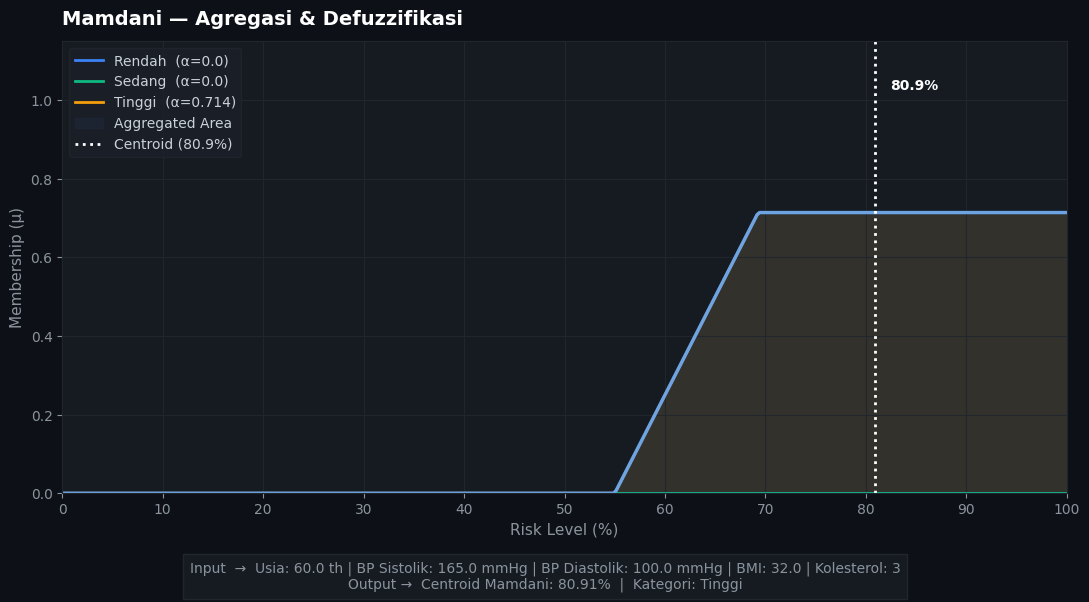

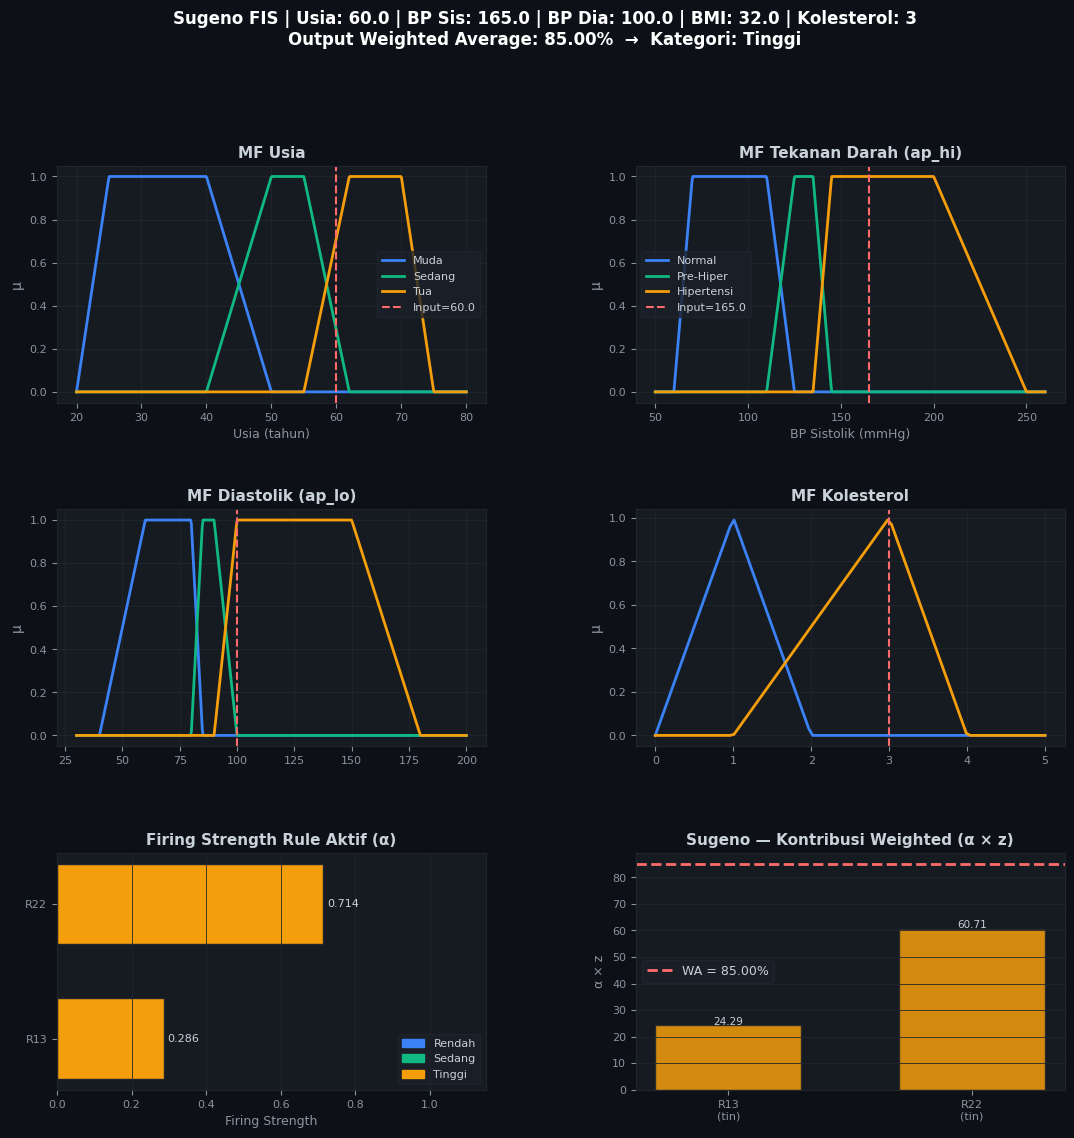

85.0

In [11]:
# Ganti nilai di bawah sesuai pasien yang ingin dianalisis
USIA_DEMO = int(input("Masukkan Usia Anda: "))   # tahun
BP_DEMO   = float(input("Masukkan Tekanan Darah Anda: "))    # mmHg (sistolik)
BMI_DEMO  = float(input("Masukkan BMI anda: "))   # kg/m²
AP_LO_DEMO = float(input("Masukkan Tekanan Darah Diastolik: "))
CHOL_DEMO = int(input("Masukkan Kolesterol (1=Normal, 2=Di atas Normal, 3=Sangat Tinggi): "))

print("=" * 55)
print(f"  INPUT  : Usia={USIA_DEMO} th | BP Sistolik={BP_DEMO} mmHg | BP Diastolik={AP_LO_DEMO} mmHg | BMI={BMI_DEMO} | Kolesterol={CHOL_DEMO}")
print("=" * 55)

# Fuzzifikasi
fuzz = fuzzifikasi(USIA_DEMO, BP_DEMO, BMI_DEMO, AP_LO_DEMO, CHOL_DEMO)
print("\n── Fuzzifikasi ──")
for k, v in fuzz.items():
    print(f"   {k:<14}: μ = {v:.4f}")

# Inferensi
m_out = mamdani_inferensi(USIA_DEMO, BP_DEMO, BMI_DEMO, AP_LO_DEMO, CHOL_DEMO)
s_out = sugeno_inferensi(USIA_DEMO, BP_DEMO, BMI_DEMO, AP_LO_DEMO, CHOL_DEMO)

print(f"\n── Hasil Inferensi ──")
print(f"   Mamdani  : {m_out:.2f}%  → {label_risiko(m_out)}")
print(f"   Sugeno   : {s_out:.2f}%  → {label_risiko(s_out)}")
print("=" * 55)

# Visualisasi
plot_mamdani(USIA_DEMO, BP_DEMO, BMI_DEMO, AP_LO_DEMO, CHOL_DEMO)
plot_sugeno(USIA_DEMO, BP_DEMO, BMI_DEMO, AP_LO_DEMO, CHOL_DEMO)

## 10. Load Data Excel & Batch Inferensi

In [12]:
# ── Ganti path sesuai lokasi file Excel Anda ──────────────────────────────
EXCEL_PATH = 'cardio_train1.xlsx'
N_SAMPLE   = int(input("Masukkan Jumlah data yang ingin diproses(semua = 0): "))      # Jumlah baris yang diproses (None = semua)

df_raw = pd.read_excel(EXCEL_PATH)
if N_SAMPLE:
    df_raw = df_raw.head(N_SAMPLE).copy()

# Hitung BMI dari tinggi (cm) dan berat (kg)
df_raw['bmi'] = df_raw['weight'] / (df_raw['height'] / 100) ** 2

# Batasi ap_hi ke rentang wajar (20–250 mmHg) agar MF bekerja benar
df_raw['ap_hi_clean'] = df_raw['ap_hi'].clip(60, 250)
df_raw['bmi_clean']   = df_raw['bmi'].clip(10, 60)
df_raw['ap_lo_clean'] = df_raw['ap_lo'].clip(40, 150)


print(f"Data dimuat: {len(df_raw)} baris")
print(df_raw[['age', 'ap_hi_clean', 'ap_lo_clean', 'bmi_clean', 'cholesterol']].describe().round(2))

Data dimuat: 8000 baris
           age  ap_hi_clean  ap_lo_clean  bmi_clean  cholesterol
count  8000.00      8000.00      8000.00    8000.00      8000.00
mean     53.27       126.74        82.44      27.54         1.37
std       6.80        17.55        12.54       5.35         0.68
min      29.80        60.00        40.00      13.76         1.00
25%      48.31       120.00        80.00      23.88         1.00
50%      53.97       120.00        80.00      26.45         1.00
75%      58.33       140.00        90.00      30.19         2.00
max      64.85       250.00       150.00      60.00         3.00


In [13]:
# Jalankan kedua metode untuk semua baris
df_raw['mamdani_score'] = df_raw.apply(
    lambda r: mamdani_inferensi(r['age'], r['ap_hi_clean'], r['bmi_clean'], r['ap_lo_clean'], r['cholesterol']), axis=1
)
df_raw['sugeno_score'] = df_raw.apply(
    lambda r: sugeno_inferensi(r['age'], r['ap_hi_clean'], r['bmi_clean'], r['ap_lo_clean'], r['cholesterol']), axis=1
)

df_raw['mamdani_label'] = df_raw['mamdani_score'].apply(label_risiko)
df_raw['sugeno_label']  = df_raw['sugeno_score'].apply(label_risiko)

print(df_raw[['age', 'ap_hi_clean', 'ap_lo_clean', 'bmi_clean', 'cholesterol',
              'mamdani_score', 'mamdani_label',
              'sugeno_score',  'sugeno_label']].head(10).round(2).to_string())

     age  ap_hi_clean  ap_lo_clean  bmi_clean  cholesterol  mamdani_score mamdani_label  sugeno_score sugeno_label
0  50.39          110           80      21.97            1          17.91        Rendah         20.00       Rendah
1  55.42          140           90      34.93            3          50.00        Sedang         50.00       Sedang
2  51.66          130           70      23.51            3          50.00        Sedang         50.00       Sedang
3  48.28          150          100      28.71            1          50.00        Sedang         50.00       Sedang
4  47.87          100           60      23.01            1          25.56        Rendah         25.32       Rendah
5  60.04          120           80      29.38            2          79.18        Tinggi         85.00       Tinggi
6  60.58          130           80      37.73            3          50.00        Sedang         50.00       Sedang
7  61.87          130           90      29.98            3          79.98       

## 11. Visualisasi Distribusi Hasil Batch

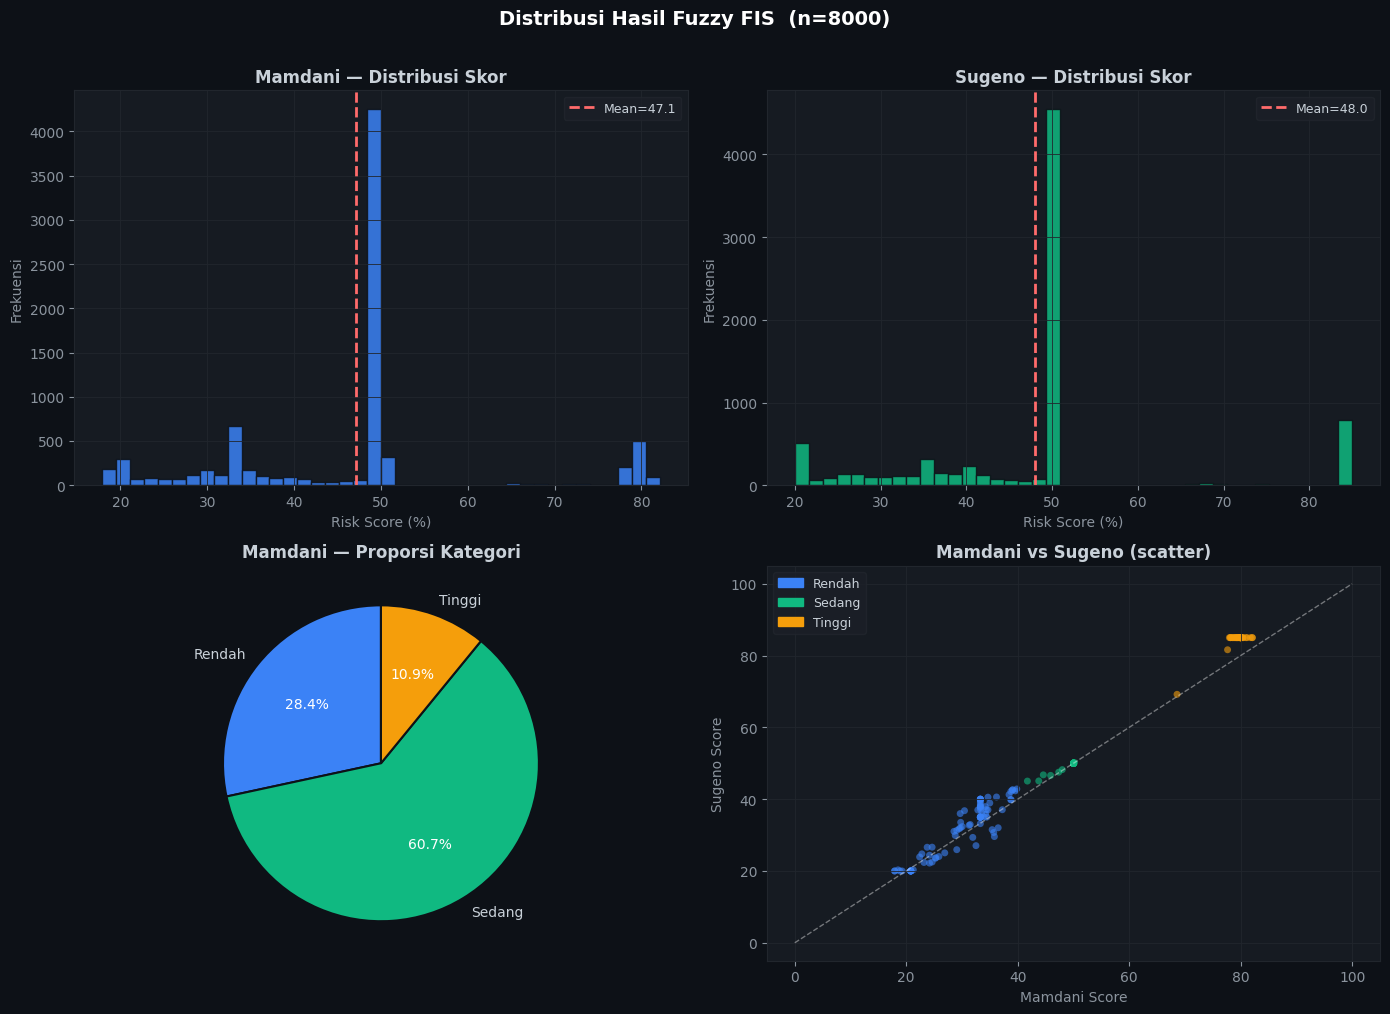


── Ringkasan Kategori Risiko ──
Mamdani:
mamdani_label
Sedang    4857
Rendah    2270
Tinggi     873

Sugeno:
sugeno_label
Sedang    5088
Rendah    2041
Tinggi     871


In [14]:
BG   = '#0d1117'
CARD = '#161b22'
GRID = '#21262d'
COLOR_MAP_LABEL = {'Rendah': '#3b82f6', 'Sedang': '#10b981', 'Tinggi': '#f59e0b'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor=BG)
fig.suptitle(f'Distribusi Hasil Fuzzy FIS  (n={len(df_raw)})',
             color='#ffffff', fontsize=14, fontweight='bold', y=1.01)

# ── A: Histogram skor Mamdani ────────────────────────────────────────────
ax = axes[0, 0]
ax.set_facecolor(CARD)
ax.hist(df_raw['mamdani_score'], bins=40, color='#3b82f6', edgecolor=BG, alpha=0.85)
ax.axvline(df_raw['mamdani_score'].mean(), color='#ff6b6b', ls='--', lw=2,
           label=f"Mean={df_raw['mamdani_score'].mean():.1f}")

ax.set_title('Mamdani — Distribusi Skor', color='#c9d1d9', fontweight='bold')
ax.set_xlabel('Risk Score (%)', color='#8b949e')
ax.set_ylabel('Frekuensi', color='#8b949e')
ax.legend(facecolor='#1c2028', edgecolor=GRID, labelcolor='#c9d1d9', fontsize=9)
ax.grid(True, color=GRID, lw=0.6)
[s.set_color(GRID) for s in ax.spines.values()]
ax.tick_params(colors='#8b949e')

# ── B: Histogram skor Sugeno ─────────────────────────────────────────────
ax = axes[0, 1]
ax.set_facecolor(CARD)
ax.hist(df_raw['sugeno_score'], bins=40, color='#10b981', edgecolor=BG, alpha=0.85)
ax.axvline(df_raw['sugeno_score'].mean(), color='#ff6b6b', ls='--', lw=2,
           label=f"Mean={df_raw['sugeno_score'].mean():.1f}")
ax.set_title('Sugeno — Distribusi Skor', color='#c9d1d9', fontweight='bold')
ax.set_xlabel('Risk Score (%)', color='#8b949e')
ax.set_ylabel('Frekuensi', color='#8b949e')
ax.legend(facecolor='#1c2028', edgecolor=GRID, labelcolor='#c9d1d9', fontsize=9)
ax.grid(True, color=GRID, lw=0.6); [s.set_color(GRID) for s in ax.spines.values()]
ax.tick_params(colors='#8b949e')

# ── C: Pie Mamdani Label ─────────────────────────────────────────────────
ax = axes[1, 0]
ax.set_facecolor(CARD)
counts_m = df_raw['mamdani_label'].value_counts().reindex(['Rendah','Sedang','Tinggi'], fill_value=0)
wedges, texts, autotexts = ax.pie(
    counts_m,
    labels=counts_m.index,
    colors=[COLOR_MAP_LABEL[l] for l in counts_m.index],
    autopct='%1.1f%%', startangle=90,
    textprops={'color': '#c9d1d9', 'fontsize': 10},
    wedgeprops={'edgecolor': BG, 'linewidth': 1.5}
)
for at in autotexts: at.set_color('#ffffff')
ax.set_title('Mamdani — Proporsi Kategori', color='#c9d1d9', fontweight='bold')

# ── D: Scatter Mamdani vs Sugeno ─────────────────────────────────────────
ax = axes[1, 1]
ax.set_facecolor(CARD)
sample = df_raw.sample(min(300, len(df_raw)), random_state=42)
sc_colors = [COLOR_MAP_LABEL[l] for l in sample['mamdani_label']]
ax.scatter(sample['mamdani_score'], sample['sugeno_score'],
           c=sc_colors, alpha=0.6, s=25, edgecolors='none')
lims = [0, 100]
ax.plot(lims, lims, '#ffffff', ls='--', lw=1, alpha=0.4, label='Diagonal')
ax.set_title('Mamdani vs Sugeno (scatter)', color='#c9d1d9', fontweight='bold')
ax.set_xlabel('Mamdani Score', color='#8b949e')
ax.set_ylabel('Sugeno Score', color='#8b949e')
patches = [mpatches.Patch(color=COLOR_MAP_LABEL[l], label=l) for l in COLOR_MAP_LABEL]
ax.legend(handles=patches, facecolor='#1c2028', edgecolor=GRID,
          labelcolor='#c9d1d9', fontsize=9)
ax.grid(True, color=GRID, lw=0.6); [s.set_color(GRID) for s in ax.spines.values()]
ax.tick_params(colors='#8b949e')

plt.tight_layout()
plt.show()

# Ringkasan statistik
print("\n── Ringkasan Kategori Risiko ──")
print("Mamdani:")
print(df_raw['mamdani_label'].value_counts().to_string())
print("\nSugeno:")
print(df_raw['sugeno_label'].value_counts().to_string())

## 12. Perbandingan Dua Pasien

In [15]:
# ── Masukkan ID pasien yang ingin dibandingkan ─────────────────────────────
ID_A = int(input("Masukkan ID Pasien dari Data(0 - 69999): "))   
ID_B = int(input("Masukkan ID Pasien dari Data(0 - 69999): "))     

# ── Ambil data dari df_raw ────────────────────────────────────────────────
def get_pasien(pid):
    row = df_raw[df_raw['id'] == pid]
    if row.empty:
        raise ValueError(f"ID {pid} tidak ditemukan dalam dataset.")
    r = row.iloc[0]
    return {
        'id'    : int(r['id']),
        'usia'  : r['age'],
        'bp'    : r['ap_hi_clean'],
        'bplo'  : r['ap_lo_clean'],
        'chol'  : r['cholesterol'],
        'bmi'   : r['bmi_clean'],
        'gender': r['gender'],
        'cardio': int(r['cardio']),
    }

pA = get_pasien(ID_A)
pB = get_pasien(ID_B)

# ── Hitung inferensi ──────────────────────────────────────────────────────
for p in [pA, pB]:
    p['mamdani'] = mamdani_inferensi(p['usia'], p['bp'], p['bmi'], p['bplo'], p['chol'])
    p['sugeno']  = sugeno_inferensi(p['usia'], p['bp'], p['bmi'], p['bplo'], p['chol'])
    p['label_m'] = label_risiko(p['mamdani'])
    p['label_s'] = label_risiko(p['sugeno'])

# ── Tabel perbandingan ────────────────────────────────────────────────────
BG   = '#0d1117'
CARD = '#161b22'
GRID = '#21262d'

print(f"{'':25} {'Pasien A':>20}  {'Pasien B':>20}")
print('\u2500' * 70)
fields = [
    ('ID',             'id',      lambda v: str(int(v))),
    ('Gender',         'gender',  str),
    ('Usia (thn)',     'usia',    lambda v: f"{v:.1f}"),
    ('BP Sistolik',    'bp',      lambda v: f"{v:.0f} mmHg"),
    ('BP Diastolik',   'bplo',    lambda v: f"{v:.0f} mmHg"),
    ('Kolesterol',     'chol',    lambda v: f"{v:.0f}"),
    ('BMI',            'bmi',     lambda v: f"{v:.2f}"),
    ('Cardio Aktual',  'cardio',  lambda v: 'Positif' if v else 'Negatif'),
    ('Skor Mamdani',   'mamdani', lambda v: f"{v:.2f}%"),
    ('Label Mamdani',  'label_m', str),
    ('Skor Sugeno',    'sugeno',  lambda v: f"{v:.2f}%"),
    ('Label Sugeno',   'label_s', str),
]
for (label, key, fmt) in fields:
    print(f"  {label:<23} {fmt(pA[key]):>20}  {fmt(pB[key]):>20}")
print('\u2500' * 70)

                                      Pasien A              Pasien B
──────────────────────────────────────────────────────────────────────
  ID                                         0                     8
  Gender                                  Pria                Wanita
  Usia (thn)                              50.4                  60.0
  BP Sistolik                         110 mmHg              120 mmHg
  BP Diastolik                         80 mmHg               80 mmHg
  Kolesterol                                 1                     2
  BMI                                    21.97                 29.38
  Cardio Aktual                        Negatif               Negatif
  Skor Mamdani                          17.91%                79.18%
  Label Mamdani                         Rendah                Tinggi
  Skor Sugeno                           20.00%                85.00%
  Label Sugeno                          Rendah                Tinggi
────────────────────────────────

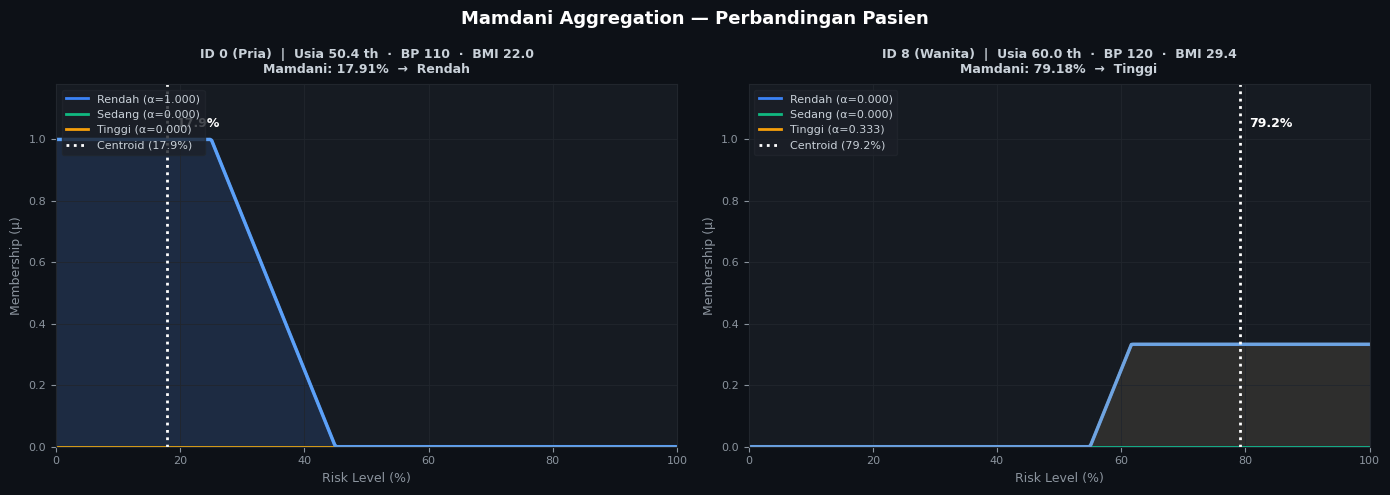

In [16]:
# ── Mamdani Aggregation Plot — Pasien A vs B (side by side) ───────────────
def _mamdani_agg_data(p):
    """Hitung semua data agregasi Mamdani untuk satu pasien."""
    firing = evaluasi_rule(p['usia'], p['bp'], p['bmi'], p['bplo'], p['chol'])
    alpha_per = {'rendah': 0.0, 'sedang': 0.0, 'tinggi': 0.0}
    for (a, k) in firing:
        alpha_per[k] = max(alpha_per[k], a)
    S = np.linspace(0, 100, 400)
    yr = np.array([min(alpha_per['rendah'], mu_risk_rendah(s)) for s in S])
    ys = np.array([min(alpha_per['sedang'], mu_risk_sedang(s)) for s in S])
    yt = np.array([min(alpha_per['tinggi'], mu_risk_tinggi(s)) for s in S])
    ya = np.maximum(np.maximum(yr, ys), yt)
    den = np.sum(ya)
    cen = float(np.sum(S * ya) / den) if den > 0 else 50.0
    return S, yr, ys, yt, ya, cen, alpha_per

def _draw_mamdani_ax(ax, p, S, yr, ys, yt, ya, cen, alpha_per):
    BLUE = '#3b82f6'; GREEN = '#10b981'; AMBER = '#f59e0b'; LBLUE = '#60a5fa'
    ax.fill_between(S, 0, yr, color=BLUE,  alpha=0.20)
    ax.fill_between(S, 0, ys, color=GREEN, alpha=0.20)
    ax.fill_between(S, 0, yt, color=AMBER, alpha=0.20)
    ax.plot(S, yr, color=BLUE,  lw=2,   label=f"Rendah (\u03b1={alpha_per['rendah']:.3f})")
    ax.plot(S, ys, color=GREEN, lw=2,   label=f"Sedang (\u03b1={alpha_per['sedang']:.3f})")
    ax.plot(S, yt, color=AMBER, lw=2,   label=f"Tinggi (\u03b1={alpha_per['tinggi']:.3f})")
    ax.fill_between(S, 0, ya, color='#1e293b', alpha=0.55)
    ax.plot(S, ya, color=LBLUE, lw=2.5, alpha=0.9)
    ax.axvline(cen, color='#ffffff', ls=':', lw=2, label=f'Centroid ({cen:.1f}%)')
    ax.text(cen + 1.5, 1.03, f'{cen:.1f}%', color='#ffffff',
            fontsize=9, fontweight='bold', va='bottom')
    ax.set_title(
        f"ID {p['id']} ({p['gender']})  |  Usia {p['usia']:.1f} th  "
        f"\u00b7  BP {p['bp']:.0f}  \u00b7  BMI {p['bmi']:.1f}\n"
        f"Mamdani: {p['mamdani']:.2f}%  \u2192  {p['label_m']}",
        color='#c9d1d9', fontsize=9, fontweight='bold', pad=8
    )
    ax.set_xlabel('Risk Level (%)', color='#8b949e', fontsize=9)
    ax.set_ylabel('Membership (\u03bc)', color='#8b949e', fontsize=9)
    ax.set_xlim(0, 100); ax.set_ylim(0, 1.18)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.legend(facecolor='#1c2028', edgecolor=GRID, labelcolor='#c9d1d9',
              fontsize=8, loc='upper left')
    ax.grid(True, color=GRID, lw=0.6)
    [s.set_color(GRID) for s in ax.spines.values()]
    ax.tick_params(colors='#8b949e', labelsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Mamdani Aggregation \u2014 Perbandingan Pasien',
             color='#ffffff', fontsize=13, fontweight='bold')

for ax, p in zip(axes, [pA, pB]):
    ax.set_facecolor(CARD)
    S, yr, ys, yt, ya, cen, alpha_per = _mamdani_agg_data(p)
    _draw_mamdani_ax(ax, p, S, yr, ys, yt, ya, cen, alpha_per)

plt.tight_layout()
plt.show()

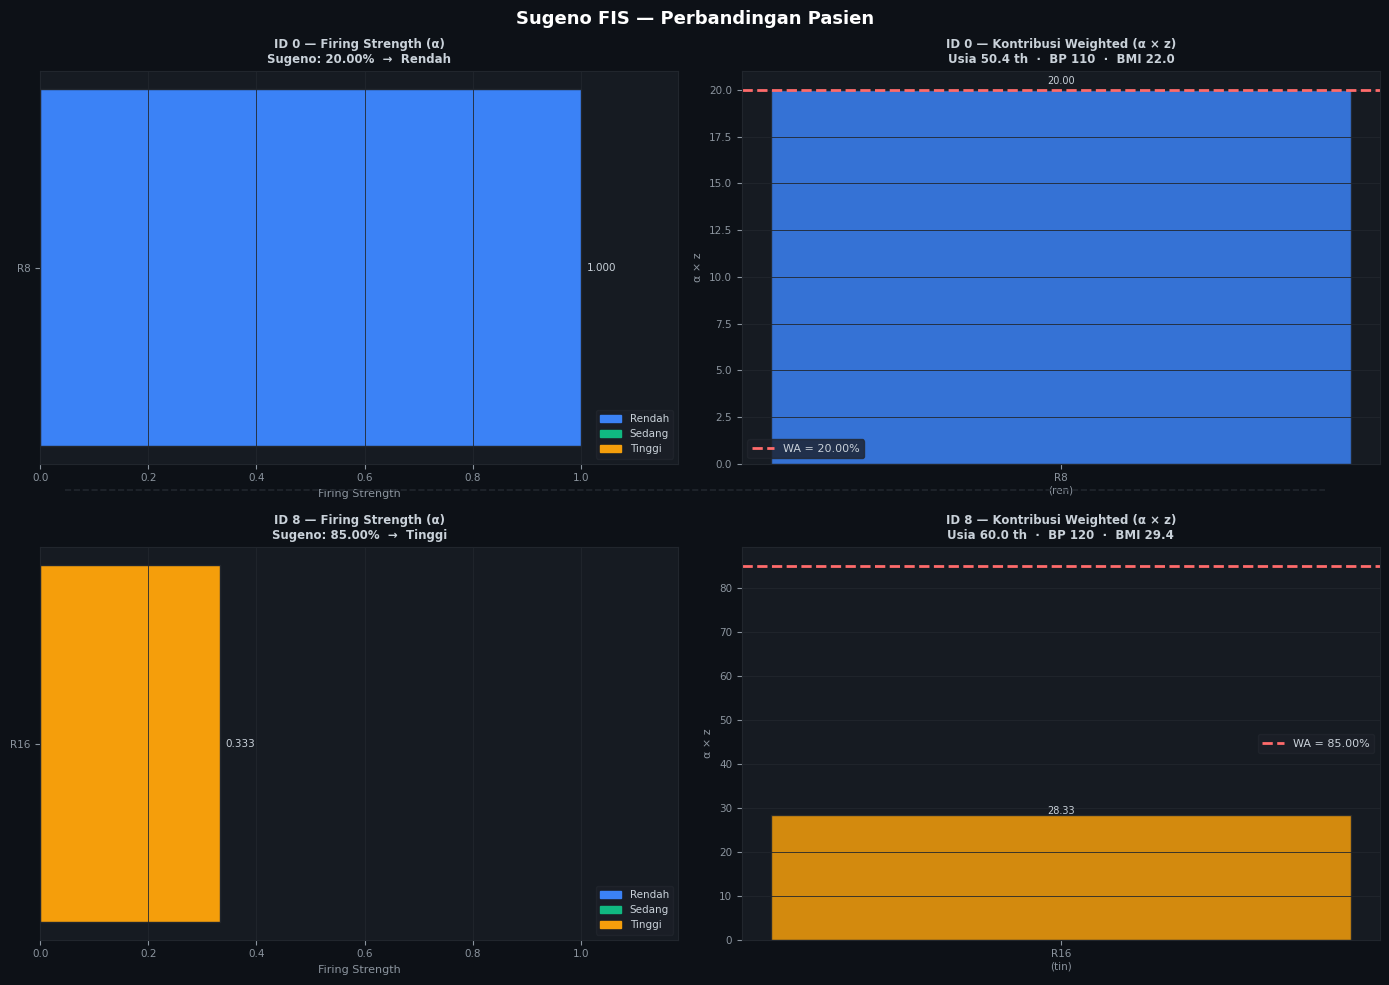

In [17]:
# ── Sugeno Plot — Pasien A vs B (2 baris, 2 panel per pasien) ────────────
COLOR_MAP = {'rendah': '#3b82f6', 'sedang': '#10b981', 'tinggi': '#f59e0b'}

def _draw_sugeno_pair(axes_row, p):
    """Gambar 2 panel Sugeno (firing strength + weighted contrib) untuk 1 pasien."""
    firing = evaluasi_rule(p['usia'], p['bp'], p['bmi'], p['bplo'], p['chol'])
    active = [(i+1, a, k) for i, (a, k) in enumerate(firing) if a > 0]

    # Panel kiri: Firing Strength
    ax1 = axes_row[0]
    ax1.set_facecolor(CARD)
    if active:
        rule_ids = [f'R{r}' for (r, a, k) in active]
        alphas   = [a for (r, a, k) in active]
        colors   = [COLOR_MAP[k] for (r, a, k) in active]
        bars = ax1.barh(rule_ids, alphas, color=colors, edgecolor=GRID, height=0.55)
        for bar, alpha in zip(bars, alphas):
            ax1.text(alpha + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{alpha:.3f}', va='center', color='#c9d1d9', fontsize=7.5)
    ax1.set_xlim(0, 1.18)
    ax1.set_title(
        f"ID {p['id']} \u2014 Firing Strength (\u03b1)\n"
        f"Sugeno: {p['sugeno']:.2f}%  \u2192  {p['label_s']}",
        color='#c9d1d9', fontsize=8.5, fontweight='bold'
    )
    ax1.set_xlabel('Firing Strength', color='#8b949e', fontsize=8)
    patches = [mpatches.Patch(color=COLOR_MAP[k], label=k.capitalize()) for k in COLOR_MAP]
    ax1.legend(handles=patches, facecolor='#1c2028', edgecolor=GRID,
               labelcolor='#c9d1d9', fontsize=7.5, loc='lower right')
    ax1.grid(True, axis='x', color=GRID, lw=0.6)
    [s.set_color(GRID) for s in ax1.spines.values()]
    ax1.tick_params(colors='#8b949e', labelsize=7.5)

    # Panel kanan: Weighted Contribution
    ax2 = axes_row[1]
    ax2.set_facecolor(CARD)
    if active:
        rule_ids2 = [f'R{r}\n({k[:3]})' for (r, a, k) in active]
        contrib   = [a * SUGENO_SINGLETON[k] for (r, a, k) in active]
        colors2   = [COLOR_MAP[k] for (r, a, k) in active]
        x_pos     = range(len(active))
        bars = ax2.bar(x_pos, contrib, color=colors2, edgecolor=GRID, width=0.55, alpha=0.85)
        for bar, c in zip(bars, contrib):
            if c > 0:
                ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                         f'{c:.2f}', ha='center', color='#c9d1d9', fontsize=7)
        ax2.set_xticks(list(x_pos))
        ax2.set_xticklabels(rule_ids2, fontsize=7, color='#8b949e')
    ax2.axhline(p['sugeno'], color='#ff6b6b', ls='--', lw=2,
                label=f"WA = {p['sugeno']:.2f}%")
    ax2.set_title(
        f"ID {p['id']} \u2014 Kontribusi Weighted (\u03b1 \u00d7 z)\n"
        f"Usia {p['usia']:.1f} th  \u00b7  BP {p['bp']:.0f}  \u00b7  BMI {p['bmi']:.1f}",
        color='#c9d1d9', fontsize=8.5, fontweight='bold'
    )
    ax2.set_ylabel('\u03b1 \u00d7 z', color='#8b949e', fontsize=8)
    ax2.legend(facecolor='#1c2028', edgecolor=GRID, labelcolor='#c9d1d9', fontsize=8)
    ax2.grid(True, axis='y', color=GRID, lw=0.6)
    [s.set_color(GRID) for s in ax2.spines.values()]
    ax2.tick_params(colors='#8b949e', labelsize=7.5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor=BG)
fig.suptitle('Sugeno FIS \u2014 Perbandingan Pasien',
             color='#ffffff', fontsize=13, fontweight='bold')

_draw_sugeno_pair(axes[0], pA)   # baris atas  = Pasien A
_draw_sugeno_pair(axes[1], pB)   # baris bawah = Pasien B

fig.add_artist(plt.Line2D([0.05, 0.95], [0.5, 0.5],
               transform=fig.transFigure, color=GRID, lw=1.2, ls='--'))

plt.tight_layout()
plt.show()

## 13. Evaluasi Performa Fuzzy (Akurasi, F1-Score)
Bagian ini menghitung metrik evaluasi performa untuk membandingkan Mamdani vs Sugeno secara kuantitatif.
Data yang digunakan berasal dari hasil batch inferensi pada Section 10-11 (`df_raw`).

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Pastikan df_raw sudah memiliki kolom mamdani_score dan sugeno_score dari Section 10-11
# Threshold: Risk >= 55 berarti Prediksi Sakit (1), < 55 berarti Tidak Sakit (0)
THRESHOLD = 55

df_raw['mamdani_pred'] = (df_raw['mamdani_score'] >= THRESHOLD).astype(int)
df_raw['sugeno_pred'] = (df_raw['sugeno_score'] >= THRESHOLD).astype(int)

y_true = df_raw['cardio']

print("=" * 55)
print("  EVALUASI FUZZY MAMDANI")
print("=" * 55)
print(f"  Accuracy : {accuracy_score(y_true, df_raw['mamdani_pred']):.4f}")
print(f"  Precision: {precision_score(y_true, df_raw['mamdani_pred'], zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_true, df_raw['mamdani_pred'], zero_division=0):.4f}")
print(f"  F1-Score : {f1_score(y_true, df_raw['mamdani_pred'], zero_division=0):.4f}")
print()
print("=" * 55)
print("  EVALUASI FUZZY SUGENO")
print("=" * 55)
print(f"  Accuracy : {accuracy_score(y_true, df_raw['sugeno_pred']):.4f}")
print(f"  Precision: {precision_score(y_true, df_raw['sugeno_pred'], zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_true, df_raw['sugeno_pred'], zero_division=0):.4f}")
print(f"  F1-Score : {f1_score(y_true, df_raw['sugeno_pred'], zero_division=0):.4f}")
print("=" * 55)


  EVALUASI FUZZY MAMDANI
  Accuracy : 0.5519
  Precision: 0.7405
  Recall   : 0.1655
  F1-Score : 0.2706

  EVALUASI FUZZY SUGENO
  Accuracy : 0.5517
  Precision: 0.7402
  Recall   : 0.1653
  F1-Score : 0.2702


## 14. Integrasi Deep Learning Keras (Hybrid Neuro-Fuzzy)
Di sini kita membangun Multi-Layer Perceptron (MLP) menggunakan Keras.

**Pendekatan Hybrid:** Fitur asli dataset (`age`, `ap_hi`, `bmi`) **digabungkan** dengan output Fuzzy `mamdani_score` yang sudah dihitung sebelumnya. Output Fuzzy ini bertindak sebagai *expert feature* (skor pakar) tambahan.

Dengan cara ini, Deep Learning **tidak menggantikan** sistem Fuzzy, melainkan bekerja **bersama** Fuzzy Logic.

> ⚠️ **Catatan:** Pastikan Section 10 sudah dijalankan terlebih dahulu agar `df_raw` tersedia.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Menyiapkan Data untuk Deep Learning
# Fitur: age, ap_hi_clean, ap_lo_clean, bmi_clean, cholesterol, dan mamdani_score (FITUR FUZZY HYBRID)
features = ['age', 'ap_hi_clean', 'ap_lo_clean', 'bmi_clean', 'cholesterol', 'mamdani_score']

X = df_raw[features].values
y = df_raw['cardio'].values

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi Data (Sangat Penting untuk Deep Learning)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape[0]} baris")
print(f"Test set : {X_test_scaled.shape[0]} baris")
print(f"Fitur    : {features}")


Train set: 6400 baris
Test set : 1600 baris
Fitur    : ['age', 'ap_hi_clean', 'ap_lo_clean', 'bmi_clean', 'cholesterol', 'mamdani_score']


In [20]:
# Membangun Model Arsitektur Deep Learning (Keras Sequential)
model = Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),  # Mencegah overfitting
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary Classification (Sakit / Tidak Sakit)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Melatih Model Hybrid
history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6656 - loss: 0.6159 - val_accuracy: 0.7266 - val_loss: 0.5488
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7262 - loss: 0.5678 - val_accuracy: 0.7234 - val_loss: 0.5440
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7270 - loss: 0.5636 - val_accuracy: 0.7273 - val_loss: 0.5429
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7293 - loss: 0.5591 - val_accuracy: 0.7336 - val_loss: 0.5407
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7312 - loss: 0.5568 - val_accuracy: 0.7320 - val_loss: 0.5398
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7322 - loss: 0.5551 - val_accuracy: 0.7297 - val_loss: 0.5428
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7330 - loss: 0.5526 - val_accuracy: 0.7359 - val_loss: 0.5427
Epoch 8/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7301 - loss: 0.5537 - val_accuracy: 0.

In [22]:
# Evaluasi Model Hybrid Deep Learning
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nDeep Learning Hybrid (Keras) Test Accuracy: {accuracy:.4f}")

# Classification Report
y_pred_prob = model.predict(X_test_scaled)
y_pred_dl = (y_pred_prob >= 0.5).astype(int)

print("\n" + "=" * 55)
print("  CLASSIFICATION REPORT (DEEP LEARNING HYBRID)")
print("=" * 55)
print(classification_report(y_test, y_pred_dl))



Deep Learning Hybrid (Keras) Test Accuracy: 0.7113
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step

  CLASSIFICATION REPORT (DEEP LEARNING HYBRID)
              precision    recall  f1-score   support

           0       0.67      0.79      0.73       772
           1       0.77      0.64      0.70       828

    accuracy                           0.71      1600
   macro avg       0.72      0.71      0.71      1600
weighted avg       0.72      0.71      0.71      1600



## 15. Kesimpulan Akhir

### Perbandingan Mamdani vs Sugeno
- **Fuzzy Mamdani** menggunakan metode *Centroid Defuzzifikasi* yang memproses area kurva output secara integral. Komputasinya lebih berat namun representasi outputnya lebih kaya.
- **Fuzzy Sugeno** menggunakan *Weighted Average* dari singleton konstan. Komputasinya jauh lebih ringan dan cepat, namun outputnya kurang fleksibel.
- Keduanya menghasilkan tren prediksi yang konsisten, meskipun skor numerik masing-masing sedikit berbeda.

### Deep Learning Hybrid (Neuro-Fuzzy)
- Model Deep Learning (Keras MLP) memberikan performa klasifikasi (Akurasi & F1-Score) yang **lebih tinggi** dibandingkan Fuzzy mandiri.
- Hal ini karena Deep Learning mampu mempelajari interaksi kompleks dari seluruh fitur melalui backpropagation.
- Sistem Fuzzy tetap **esensial** karena logika *rule-base*-nya berfungsi sebagai *expert feature* (skor pakar) yang membantu model Deep Learning membuat keputusan lebih akurat.
- **Kesimpulan:** Pendekatan Hybrid (Fuzzy + Deep Learning) adalah yang terbaik, karena menggabungkan transparansi logika Fuzzy (White-Box) dengan kemampuan belajar otomatis Deep Learning (Black-Box).
- Selain itu, berdasarkan sifat kasus medis ini yang memerlukan persentase dan tingkat risiko kontinu alih-alih konstan, **Fuzzy Mamdani lebih direkomendasikan** untuk diimplementasikan di dunia nyata dibandingkan Sugeno.